In [ ]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [ ]:
# load data

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Text(0.5, 1.0, 'Distribution of Medical Charges')

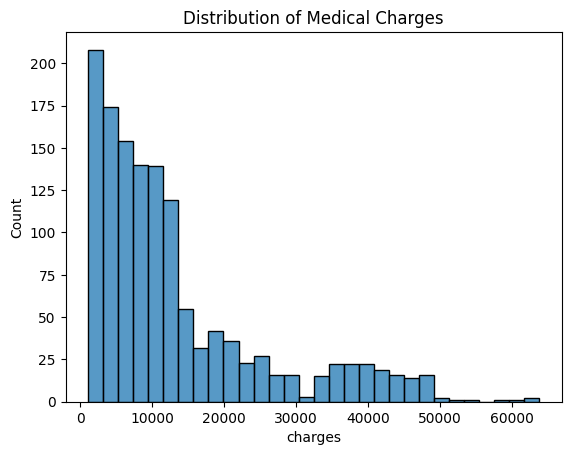

In [ ]:
# distribution of charges
sns.histplot(df['charges'])
plt.title('Distribution of Medical Charges')

<Axes: xlabel='smoker', ylabel='charges'>

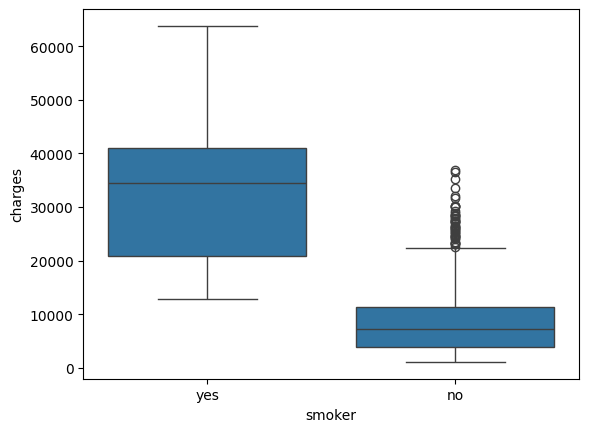

In [ ]:
# smoking impact
sns.boxplot(x='smoker', y='charges', data = df)

<Axes: xlabel='age', ylabel='charges'>

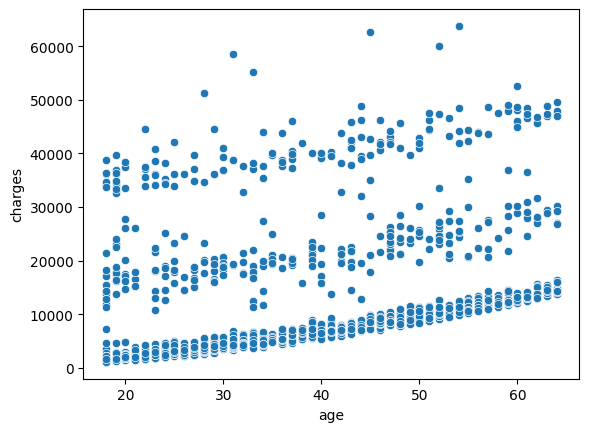

In [ ]:
# age vs charges
sns.scatterplot(x='age', y='charges', data = df)

<Axes: xlabel='region', ylabel='charges'>

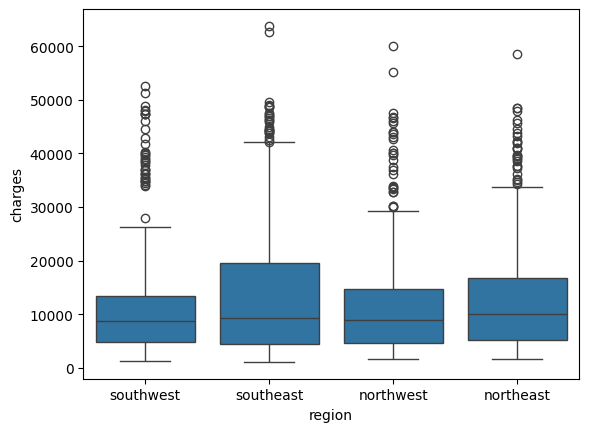

In [ ]:
# region comparison
sns.boxplot(x='region', y='charges', data = df)

# Feature Engineering

In [ ]:
# encode categorical variable
df_encoded = df.copy()

le = LabelEncoder()

df_encoded['sex'] = le.fit_transform(df_encoded['sex'])
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

In [ ]:
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [ ]:
# create a high-risk label

threshold = df_encoded['charges'].quantile(0.75)
df_encoded['high_risk'] = (df_encoded['charges'] > threshold).astype(int)

In [ ]:
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,high_risk
0,19,0,27.900,0,1,16884.92400,False,False,True,1
1,18,1,33.770,1,0,1725.55230,False,True,False,0
2,28,1,33.000,3,0,4449.46200,False,True,False,0
3,33,1,22.705,0,0,21984.47061,True,False,False,1
4,32,1,28.880,0,0,3866.85520,True,False,False,0


# Train and Test

In [ ]:
x = df_encoded.drop(['charges', 'high_risk'], axis=1)
y_reg = df_encoded['charges']
y_clf = df_encoded['high_risk']

x_train, x_test, y_train_reg, y_test_reg = train_test_split(x, y_reg, test_size = 0.2, random_state=42)
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x, y_clf, test_size = 0.2, random_state=42)

# Regression Model

In [ ]:
# train
rf_reg = RandomForestRegressor()
rf_reg.fit(x_train, y_train_reg)

RandomForestRegressor()

In [ ]:
# predict
y_pred_reg = rf_reg.predict(x_test)

print('MAE:', mean_absolute_error(y_test_reg, y_pred_reg))
print('RMSE:', np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print('R2:', r2_score(y_test_reg, y_pred_reg))

MAE: 2587.3545768952895
RMSE: 4611.903405974457
R2: 0.8629962845965936


# Classification Model

In [ ]:
# train
rf_clf = RandomForestClassifier()
rf_clf.fit(x_train_c, y_train_c)

RandomForestClassifier()

In [ ]:
# predict
y_pred_clf = rf_clf.predict(x_test_c)

print('Accuracy:', accuracy_score(y_test_c, y_pred_clf))
print(classification_report(y_test_c, y_pred_clf))

Accuracy: 0.9328358208955224
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       202
           1       0.93      0.79      0.85        66

    accuracy                           0.93       268
   macro avg       0.93      0.88      0.90       268
weighted avg       0.93      0.93      0.93       268



# Feature Importance

<Axes: xlabel='importance', ylabel='feature'>

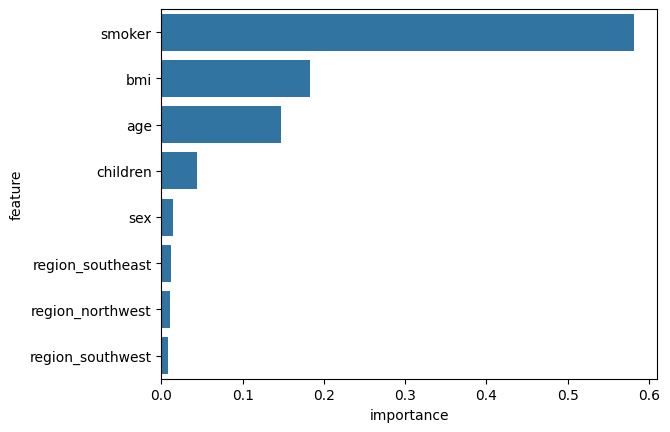

In [ ]:
importances = rf_clf.feature_importances_

feat_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feat_importance)